# Credit Card Approval Prediction


## Team Members

* Mridul Jain (20250784)
* Arunachalaeswar Chandran (20250179)
* Kezia Wibowo (20240232)
* Emiliano Gallardo Manrique (20250385)

## Github Repository

## 1. Data Cleaning

Pre-processing the Dataset to handle missing values, outliers and inconsistencies in features related to getting approval for credit card.

### 1.1 Import libraries and load data

In [1]:
import numpy as np
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving application_record.csv to application_record.csv


In [2]:
app = pd.read_csv('application_record.csv')
app
#ID	- Client number
#CODE_GENDER -	Gender
#FLAG_OWN_CAR -	Is there a car
#FLAG_OWN_REALTY -	Is there a property
#CNT_CHILDREN -	Number of children
#AMT_INCOME_TOTAL -	Annual income
#NAME_INCOME_TYPE -	Income category
#NAME_EDUCATION_TYPE -	Education level
#NAME_FAMILY_STATUS -	Marital status
#NAME_HOUSING_TYPE -	Way of living
#DAYS_BIRTH -	Birthday	Count backwards from current day (0), -1 means yesterday
#DAYS_EMPLOYED -	Start date of employment	Count backwards from current day(0). If positive, it means the person currently unemployed.
#FLAG_MOBIL -	Is there a mobile phone
#FLAG_WORK_PHONE -	Is there a work phone
#FLAG_PHONE -	Is there a phone
#FLAG_EMAIL	Is - there an email
#OCCUPATION_TYPE -	Occupation
#CNT_FAM_MEMBERS -	Family size

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


### Loading the Credit Record Dataset

The credit record dataset provides historical credit information related to each applicant.  
This dataset helps determine whether a customer has been approved or rejected based on their credit behavior.  
By linking this dataset with the application dataset using the client ID, we can build a labeled dataset for prediction.

In [3]:
uploaded = files.upload()
cc = pd.read_csv('credit_record.csv')
cc.head()

Saving credit_record.csv to credit_record.csv


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [4]:
cc

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


### 1.2 Creating the Target Variable

To perform predictive modeling, a target variable is created that indicates whether an applicant was accepted or rejected.  
This is achieved by checking whether the applicant’s ID exists in the credit record dataset.  
Applicants with a matching credit record are labeled as accepted, while others are considered rejected.

In [7]:
app['Status'] = app['ID'].isin(cc['ID']).astype(int)
app

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Status
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0,0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0,0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0,0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0,0


## Checking the Distribution of Accepted and Rejected Applicants

Understanding the distribution of accepted and rejected applicants helps identify whether the dataset is balanced or imbalanced.  
This step provides insight into how many applicants fall into each category, which is important when building classification models.

In [8]:
# Checking the number of people who got accepted and rejected.
app['Status'].value_counts()
#1 means accepted 0 rejected

,count
Status,
0,402100
1,36457


## 1.3 Check missing values and irregularities

In [9]:
# Looking for missing values and duplicates in the dataset
print('Duplicates',app.duplicated().sum())
app.isnull().sum()

Duplicates 0


,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [10]:
# As there are many null values in OCCUPATION_TYPE, lets check unique values in that column.
app['OCCUPATION_TYPE'].unique()


array([nan, 'Security staff', 'Sales staff', 'Accountants', 'Laborers',
       'Managers', 'Drivers', 'Core staff', 'High skill tech staff',
       'Cleaning staff', 'Private service staff', 'Cooking staff',
       'Low-skill Laborers', 'Medicine staff', 'Secretaries',
       'Waiters/barmen staff', 'HR staff', 'Realty agents', 'IT staff'],
      dtype=object)

In [11]:
# There is another column with the income category where there is Pensioner, this might have null values in the OCCUPATION_TYPE.
# We can replace these null values with "Retired"
# First let's check values in the Occupation tyype column when the applicant is a pensioner.
app[app['NAME_INCOME_TYPE'] == 'Pensioner']['OCCUPATION_TYPE'].unique()


array([nan, 'Core staff', 'Laborers', 'Low-skill Laborers', 'Drivers',
       'Accountants', 'Managers', 'Medicine staff', 'Cooking staff',
       'Security staff', 'Sales staff', 'High skill tech staff',
       'Secretaries'], dtype=object)

In [12]:
# We can see that there are various occupations in that column but a Pensioner must be retired otherwise it must reflect as working
# Changing the values from other occupations to Retired
app.loc[app['NAME_INCOME_TYPE'] == 'Pensioner', 'OCCUPATION_TYPE'] = 'Retired'
#this means if the income type listed as pensioner and also if they have a null value , their occupation will be listed as Retired

In [13]:
# Fill OCCUPATION_TYPE with 'Unemployed' where DAYS_EMPLOYED is positive as remarks provided by author
app.loc[app['DAYS_EMPLOYED'] > 0, 'OCCUPATION_TYPE'] = 'Unemployed'

In [14]:
# Checking further missing values
app.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [15]:
# Checking if we can remove the null values using the 5% Threshold rule
# If < 5% missing: Drop the rows
print('Percentage of Missing values in OCCUPATION_TYPE by the entire data set = ',(app['OCCUPATION_TYPE'].isnull().sum() / len(app)) * 100)

Percentage of Missing values in OCCUPATION_TYPE by the entire data set =  13.418096165378731


### Evaluating Missing Data Mechanism

To determine whether missing values can be safely removed, the missing data mechanism is examined.  
If the missing values are considered Missing Completely at Random (MCAR), removing them will not introduce bias into the dataset.  
Based on the similarity of acceptance rates between groups, the missing data is treated as MCAR and can be safely dropped.

In [16]:
# As the % of missing values is > than 5% we need to calculate the Randomness factor
# MCAR (Missing Completely at Random) - if yes remove
# MNAR (Missing Not at Random) - if yes replace null values with "Other"
# Comparing acceptance rates for missing vs. non-missing values in OCCUPATION_TYPE
print("Acceptance rate where Occupation is MISSING:", app[app['OCCUPATION_TYPE'].isnull()]['Status'].mean())
print("\nAcceptance rate where Occupation is PROVIDED:", app[app['OCCUPATION_TYPE'].notnull()]['Status'].mean())

Acceptance rate where Occupation is MISSING: 0.08809434795907962

Acceptance rate where Occupation is PROVIDED: 0.08236000537250698


In [17]:
# As the rates are similar, the data is likely Missing Completely at Random. Which means we can safely drop this data.
# Logic behind this is that the applicants who had their occupation stated and the ones who not have a simmilar acceptance rate.
# So, even if we drop them, it does not effect our analysis.
app = app.dropna(subset=['OCCUPATION_TYPE']).reset_index(drop=True)
app.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


### Creating Age Variable

The original dataset stores age information in terms of the number of days since birth.  
To make the data more interpretable, this value is converted into age in years.  
Feature engineering steps like this help improve the interpretability and usefulness of the dataset.

In [18]:
# Converting DAYS_BIRTH to Age (Years)
# We take the absolute value, divide by 365.25, and round to 0 decimal place
app['AGE'] = (np.abs(app['DAYS_BIRTH']) / 365.25).round(0)

# Converting DAYS_EMPLOYED to YEARS_EMPLOYED
# if positive -> 0, otherwise absolute days / 365.25
app['YEARS_EMPLOYED'] = app['DAYS_EMPLOYED'].apply(lambda x: 0 if x > 0 else (abs(x) / 365.25))
app['YEARS_EMPLOYED'] = app['YEARS_EMPLOYED'].round(1)

# Cleaning up the original 'DAYS' columns as we don't need them anymore
app = app.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'])

# View results
print(app[['AGE', 'YEARS_EMPLOYED']])

         AGE  YEARS_EMPLOYED
0       59.0             3.1
1       52.0             8.4
2       52.0             8.4
3       52.0             8.4
4       52.0             8.4
...      ...             ...
379706  62.0             0.0
379707  44.0             8.2
379708  22.0             1.0
379709  59.0             0.0
379710  52.0             3.3

[379711 rows x 2 columns]


In [19]:
app

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Status,AGE,YEARS_EMPLOYED
0,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,1,59.0,3.1
1,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52.0,8.4
2,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52.0,8.4
3,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52.0,8.4
4,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52.0,8.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379706,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,1,0,0,0,Unemployed,1.0,0,62.0,0.0
379707,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,1,0,0,0,Laborers,1.0,0,44.0,8.2
379708,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,1,1,0,0,Sales staff,1.0,0,22.0,1.0
379709,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,1,0,0,0,Unemployed,2.0,0,59.0,0.0


In [20]:
app.shape

(379711, 19)

In [21]:
#final data
app.to_csv('app.csv', index=False)
print("Data successfully saved to data.csv")

Data successfully saved to data.csv


## 2. DATA PROCESSING


In [22]:
data = pd.read_csv('app.csv')
data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Status,AGE,YEARS_EMPLOYED
0,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,1,59.0,3.1
1,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52.0,8.4
2,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52.0,8.4
3,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52.0,8.4
4,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52.0,8.4


In [23]:
# Checking again the number of applicants from final data who got accepted and rejected.
data['Status'].value_counts().reset_index()

,Status,count
0,0,348438
1,1,31273


In [24]:
data.shape

(379711, 19)

### 2.1 Analysis of Accepted Applicants

Various visualizations are created to examine the profile of applicants who were approved for credit cards.  
These charts help identify which demographic or financial factors may be associated with successful credit approval.

In [26]:
accepted = data[data['Status'] == 1]
accepted.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Status,AGE,YEARS_EMPLOYED
0,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,1,59.0,3.1
1,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52.0,8.4
2,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52.0,8.4
3,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52.0,8.4
4,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52.0,8.4


### 2.1.1 Years Employed

In [27]:
bins_years = [0, 4, 7, 10, 14, 17, accepted['YEARS_EMPLOYED'].max()+1]

labels_years = [
    '0-3',
    '4-6',
    '7-9',
    '10-13',
    '14-16',
    '17+'
]

# Create binned column
accepted['YEARS_EMPLOYED_RANGE'] = pd.cut(
    accepted['YEARS_EMPLOYED'],
    bins=bins_years,
    labels=labels_years,
    right=False
)

# Distribution
years_distribution = (
    accepted['YEARS_EMPLOYED_RANGE']
    .value_counts()
    .sort_index()
)

/tmp/ipykernel_664/2965241057.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accepted['YEARS_EMPLOYED_RANGE'] = pd.cut(


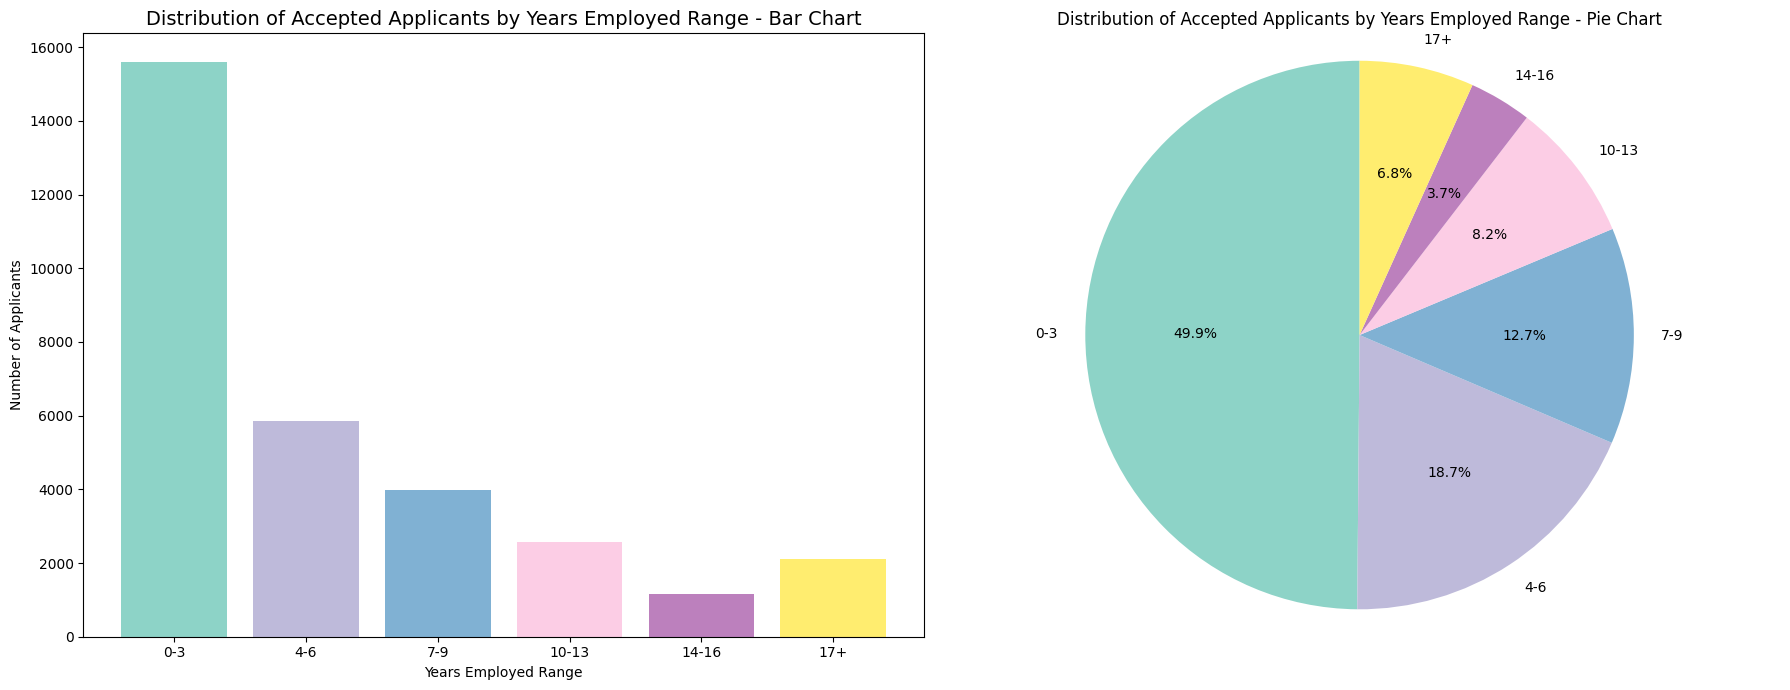

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18,7))

# Barchart
plt.subplot(1,2,1)

plt.bar(
    years_distribution.index.astype(str),
    years_distribution.values,
    color=plt.cm.Set3(np.linspace(0,1,len(years_distribution)))
)

plt.title('Distribution of Accepted Applicants by Years Employed Range - Bar Chart', fontsize=14)
plt.xlabel('Years Employed Range')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)

# Pie chart
plt.subplot(1,2,2)

wedges, texts, autotexts = plt.pie(
    years_distribution.values,
    labels=years_distribution.index.astype(str),
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3(np.linspace(0,1,len(years_distribution)))
)

plt.title('Distribution of Accepted Applicants by Years Employed Range - Pie Chart')
plt.axis('equal')

plt.tight_layout()
plt.show()

### 2.1.2 Age


In [29]:
# Custom age bins starting from 21
# Using max()+1 only if it is greater than the last defined bin to ensure uniqueness
bins_age = [21, 30, 40, 50, 60, 69, accepted['AGE'].max()+1]

labels_age = [
    '21-29',
    '30-39',
    '40-49',
    '50-59',
    '60-69',
    '70+',
]

accepted['AGE_RANGE'] = pd.cut(
    accepted['AGE'],
    bins=bins_age,
    labels=labels_age,
    right=False
)

# Distribution
age_distribution = (
    accepted['AGE_RANGE']
    .value_counts()
    .sort_index()
)
age_distribution

/tmp/ipykernel_664/1403890620.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accepted['AGE_RANGE'] = pd.cut(


,count
AGE_RANGE,
21-29,3653
30-39,8679
40-49,7924
50-59,6948
60-69,4062
70+,7


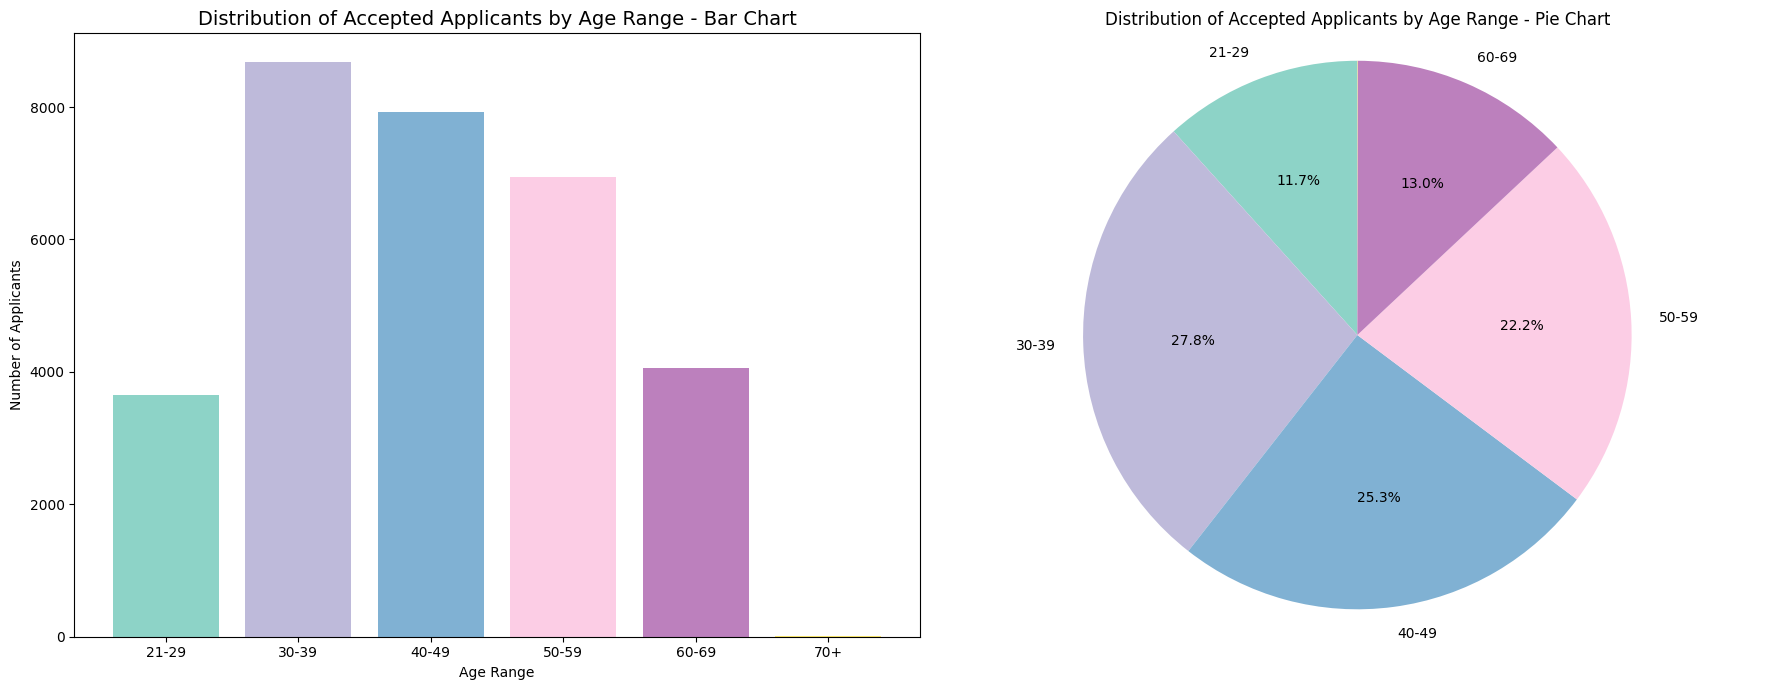

In [30]:
# Create figure
plt.figure(figsize=(18,7))

# BAR CHART
plt.subplot(1,2,1)

plt.bar(
    age_distribution.index.astype(str),
    age_distribution.values,
    color=plt.cm.Set3(np.linspace(0,1,len(age_distribution)))
)

plt.title('Distribution of Accepted Applicants by Age Range - Bar Chart', fontsize=14)
plt.xlabel('Age Range')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)

# PIE CHART
plt.subplot(1,2,2)

sorted_indices = age_distribution.argsort().tolist()
smallest_1 = sorted_indices[0]
smallest_2 = sorted_indices[1]

wedges, texts, autotexts = plt.pie(
    age_distribution.values,
    labels=age_distribution.index.astype(str),
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3(np.linspace(0,1,len(age_distribution)))
)
texts[smallest_1].set_visible(False)
autotexts[smallest_1].set_visible(False)
plt.title('Distribution of Accepted Applicants by Age Range - Pie Chart')
plt.axis('equal')

plt.tight_layout()
plt.show()

### 2.1.3 Income

In [31]:
bins_income = [0, 100000, 200000, 300000, 400000, 600000, accepted['AMT_INCOME_TOTAL'].max()+1]

labels_income = [
    '0-100k',
    '100k-200k',
    '200k-300k',
    '300k-400k',
    '400k-600k',
    '600k+'
]

accepted['INCOME_RANGE'] = pd.cut(
    accepted['AMT_INCOME_TOTAL'],
    bins=bins_income,
    labels=labels_income,
    right=False)

# Distribution
income_distribution = (
    accepted['INCOME_RANGE']
    .value_counts()
    .sort_index())

income_distribution

/tmp/ipykernel_664/3998916726.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accepted['INCOME_RANGE'] = pd.cut(


,count
INCOME_RANGE,
0-100k,4399
100k-200k,15393
200k-300k,8281
300k-400k,2162
400k-600k,782
600k+,256


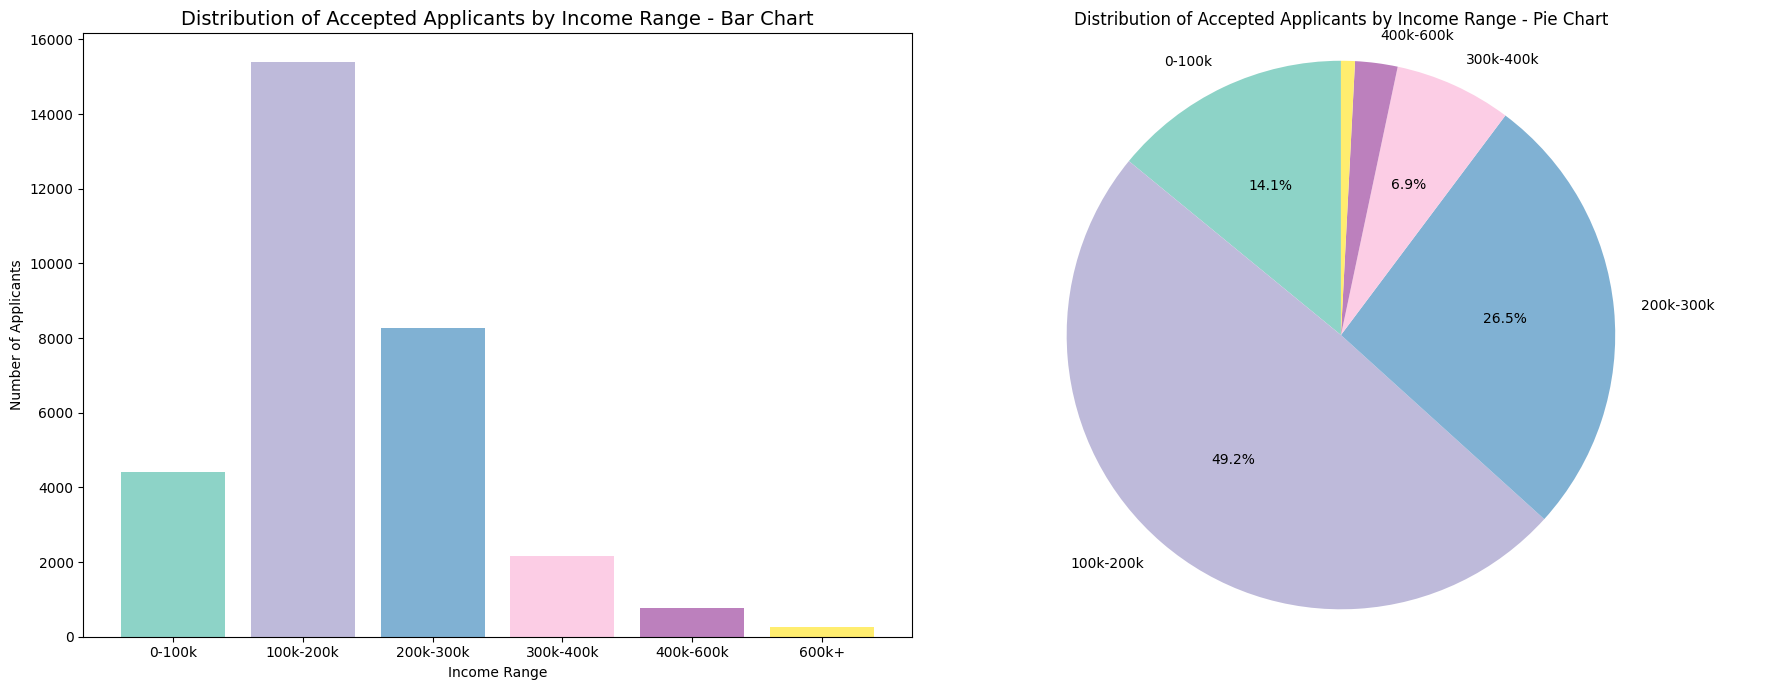

In [32]:
plt.figure(figsize=(18,7))

# BAR CHART
plt.subplot(1,2,1)

plt.bar(
    income_distribution.index.astype(str),
    income_distribution.values,
    color=plt.cm.Set3(np.linspace(0,1,len(income_distribution)))
)

plt.title('Distribution of Accepted Applicants by Income Range - Bar Chart', fontsize=14)
plt.xlabel('Income Range')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)

# PIE CHART
plt.subplot(1,2,2)

sorted_indices = income_distribution.argsort().tolist()
smallest_1 = sorted_indices[0]
smallest_2 = sorted_indices[1]

wedges, texts, autotexts = plt.pie(
    income_distribution.values,
    labels=income_distribution.index.astype(str),
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3(np.linspace(0,1,len(income_distribution)))
)

# Hide smallest slices
autotexts[smallest_1].set_visible(False)
texts[smallest_1].set_visible(False)
autotexts[smallest_2].set_visible(False)

plt.title('Distribution of Accepted Applicants by Income Range - Pie Chart')
plt.axis('equal')

plt.tight_layout()
plt.show()

### 2.1.4 Other Numerical Columns

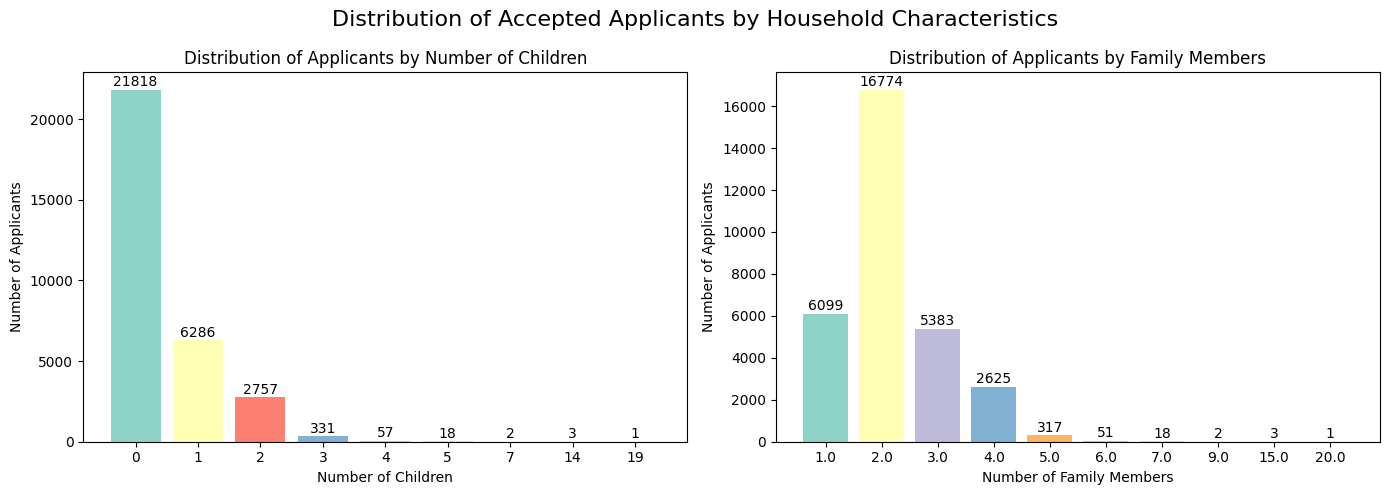

In [33]:
plt.figure(figsize=(14,5))

# CHILDREN
plt.subplot(1,2,1)

children_counts = accepted['CNT_CHILDREN'].value_counts().sort_index()

plt.bar(
    children_counts.index.astype(str),
    children_counts.values,
    color=plt.cm.Set3(np.linspace(0,1,len(children_counts)))
)

plt.title("Distribution of Applicants by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Number of Applicants")

for i,v in enumerate(children_counts.values):
    plt.text(i, v + max(children_counts.values)*0.01, str(v), ha='center')

# FAMILY MEMBER
plt.subplot(1,2,2)

family_counts = accepted['CNT_FAM_MEMBERS'].value_counts().sort_index()

plt.bar(
    family_counts.index.astype(str),
    family_counts.values,
    color=plt.cm.Set3(np.linspace(0,1,len(family_counts)))
)

plt.title("Distribution of Applicants by Family Members")
plt.xlabel("Number of Family Members")
plt.ylabel("Number of Applicants")

for i,v in enumerate(family_counts.values):
    plt.text(i, v + max(family_counts.values)*0.01, str(v), ha='center')

plt.suptitle("Distribution of Accepted Applicants by Household Characteristics", fontsize=16)

plt.tight_layout()
plt.show()

### 2.1.5 Categorical

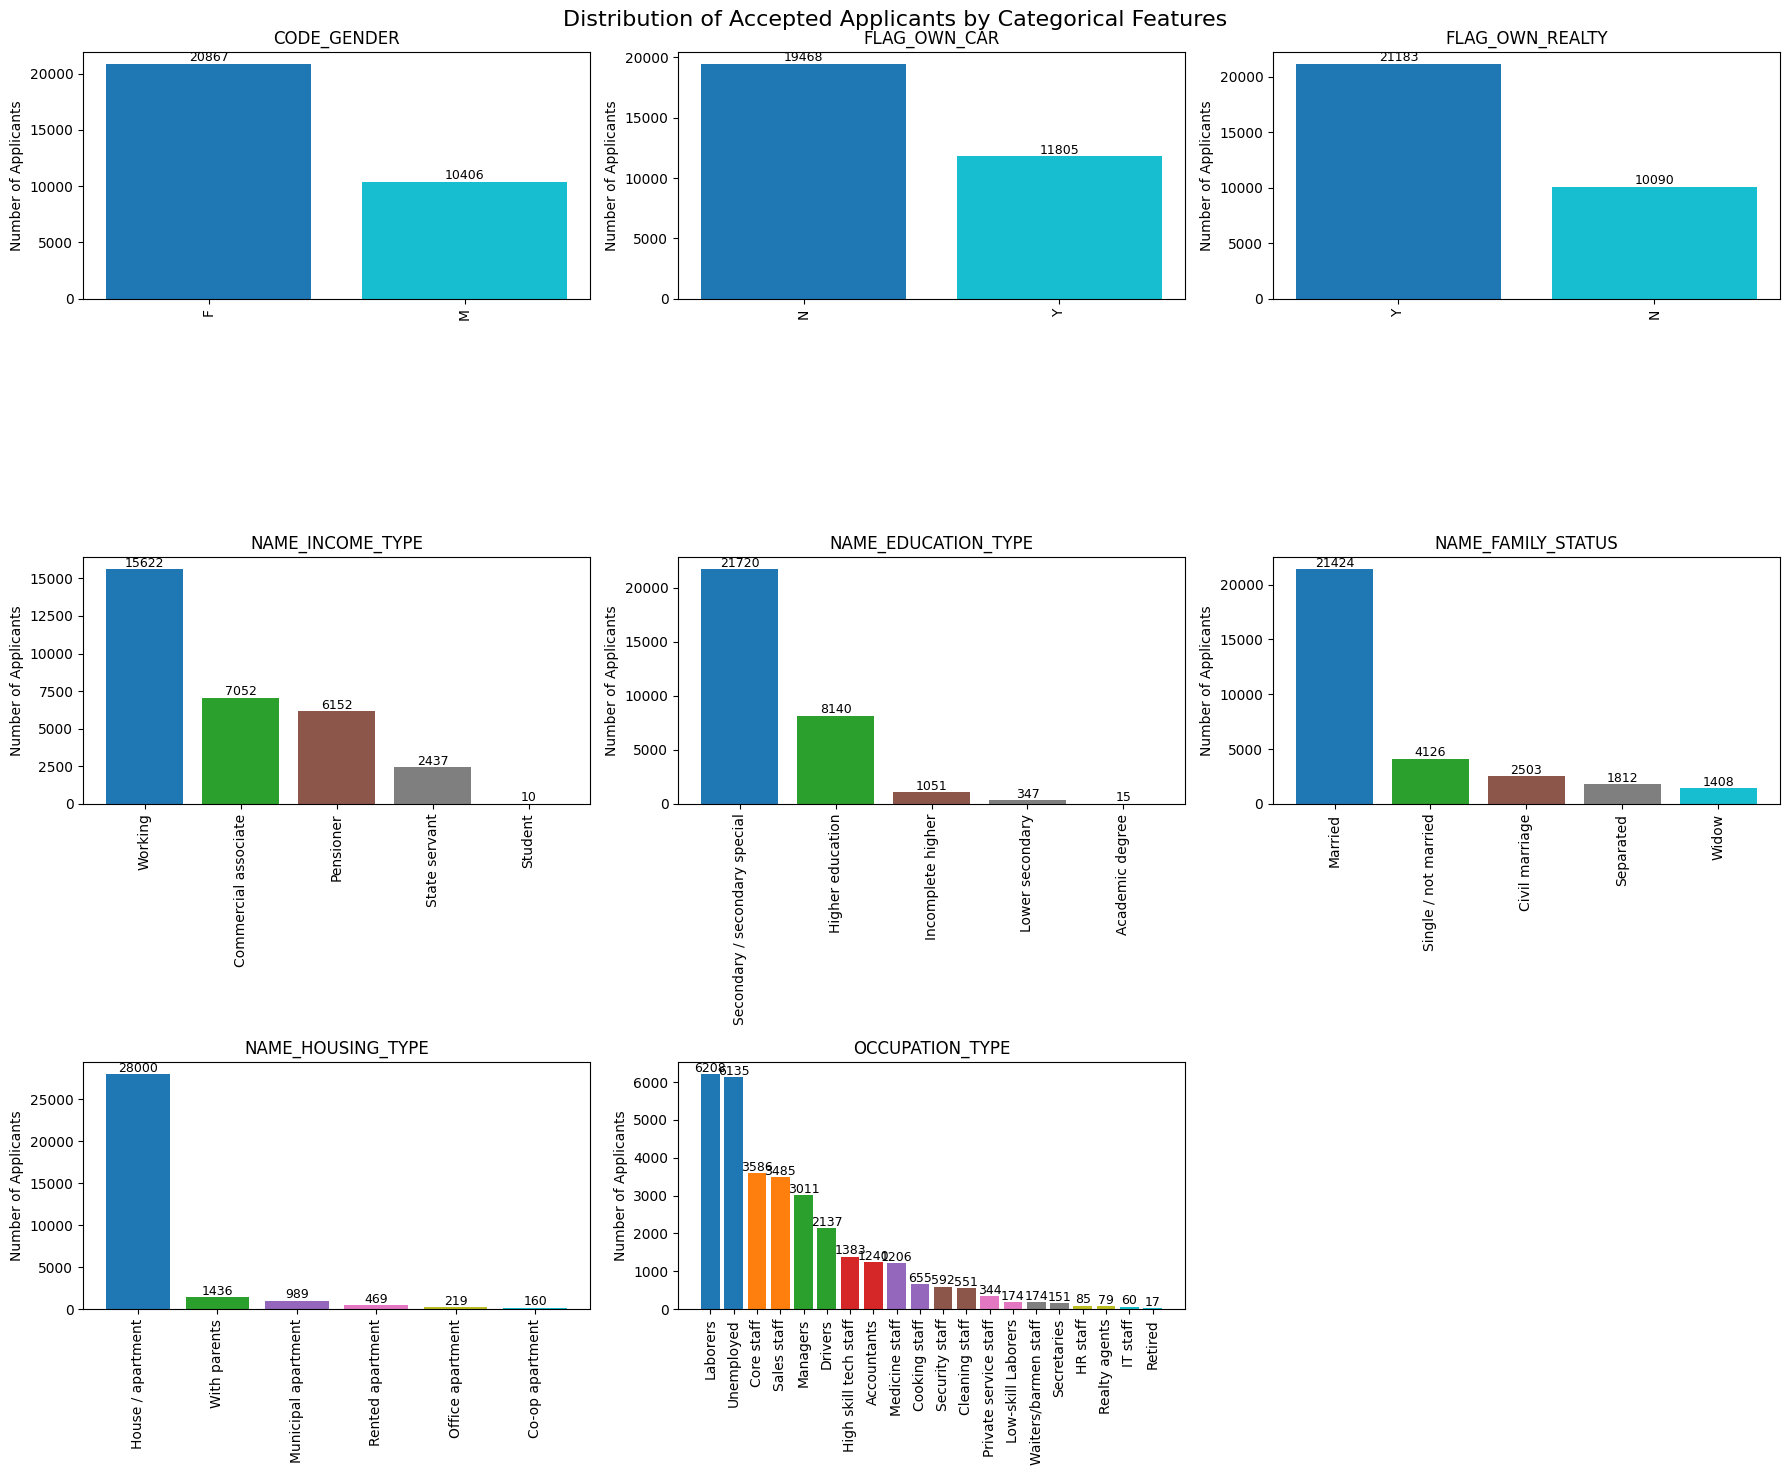

In [34]:
import math

categorical_columns = [
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]

# layout
num_cols = 3
num_rows = math.ceil(len(categorical_columns) / num_cols)

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(num_rows, num_cols, i)

    counts = accepted[col].value_counts()

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color=plt.cm.tab10(np.linspace(0, 1, len(counts)))
    )

    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Number of Applicants')
    plt.xticks(rotation=90)

    # value labels
    for j, v in enumerate(counts.values):
        plt.text(j, v + max(counts.values) * 0.01, str(v), ha='center', fontsize=9)

plt.suptitle('Distribution of Accepted Applicants by Categorical Features', fontsize=16)
plt.tight_layout()
plt.show()

### 2.2 Analysis of Rejected Applicants

Similar visualizations are generated for rejected applicants.  
Comparing these patterns with accepted applicants helps highlight the differences between the two groups and provides insights into factors that may influence credit decisions.

In [37]:
rejected = data[data['Status'] == 0]
rejected.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Status,AGE,YEARS_EMPLOYED
10,6153651,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,1,1,1,1,Accountants,2.0,0,46.0,2.1
38,6153733,M,Y,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,1,0,1,0,Drivers,2.0,0,56.0,12.2
39,6153734,M,Y,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,1,0,1,0,Drivers,2.0,0,56.0,12.2
40,6153735,M,Y,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,1,0,1,0,Drivers,2.0,0,56.0,12.2
56,6153736,F,Y,Y,2,135000.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Laborers,4.0,0,43.0,8.7


### 2.2.1 Years Employed

/tmp/ipykernel_664/1797022446.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rejected['YEARS_EMPLOYED_RANGE'] = pd.cut(


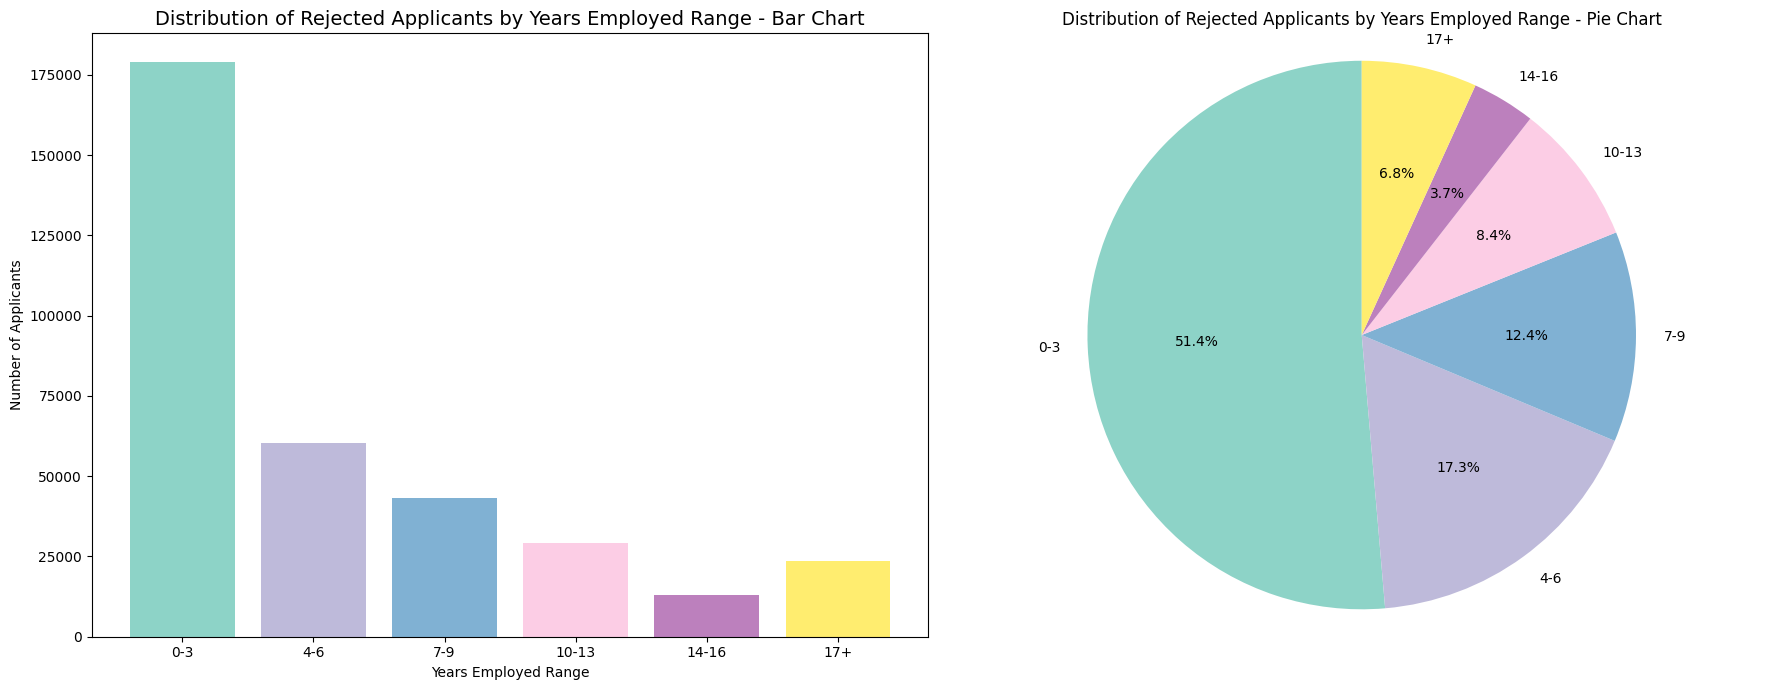

In [38]:
bins_years = [0, 4, 7, 10, 14, 17, rejected['YEARS_EMPLOYED'].max()+1]

labels_years = [
    '0-3',
    '4-6',
    '7-9',
    '10-13',
    '14-16',
    '17+'
]

# Create binned column
rejected['YEARS_EMPLOYED_RANGE'] = pd.cut(
    rejected['YEARS_EMPLOYED'],
    bins=bins_years,
    labels=labels_years,
    right=False
)

# Distribution
years_distribution_r = (
    rejected['YEARS_EMPLOYED_RANGE']
    .value_counts()
    .sort_index()
)


plt.figure(figsize=(18,7))

# Barchart
plt.subplot(1,2,1)

plt.bar(
    years_distribution_r.index.astype(str),
    years_distribution_r.values,
    color=plt.cm.Set3(np.linspace(0,1,len(years_distribution_r)))
)

plt.title('Distribution of Rejected Applicants by Years Employed Range - Bar Chart', fontsize=14)
plt.xlabel('Years Employed Range')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)

# Pie chart
plt.subplot(1,2,2)

wedges, texts, autotexts = plt.pie(
    years_distribution_r.values,
    labels=years_distribution_r.index.astype(str),
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3(np.linspace(0,1,len(years_distribution_r)))
)

plt.title('Distribution of Rejected Applicants by Years Employed Range - Pie Chart')
plt.axis('equal')

plt.tight_layout()
plt.show()

### 2.2.2 Age

/tmp/ipykernel_664/4057224145.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rejected['AGE_RANGE'] = pd.cut(


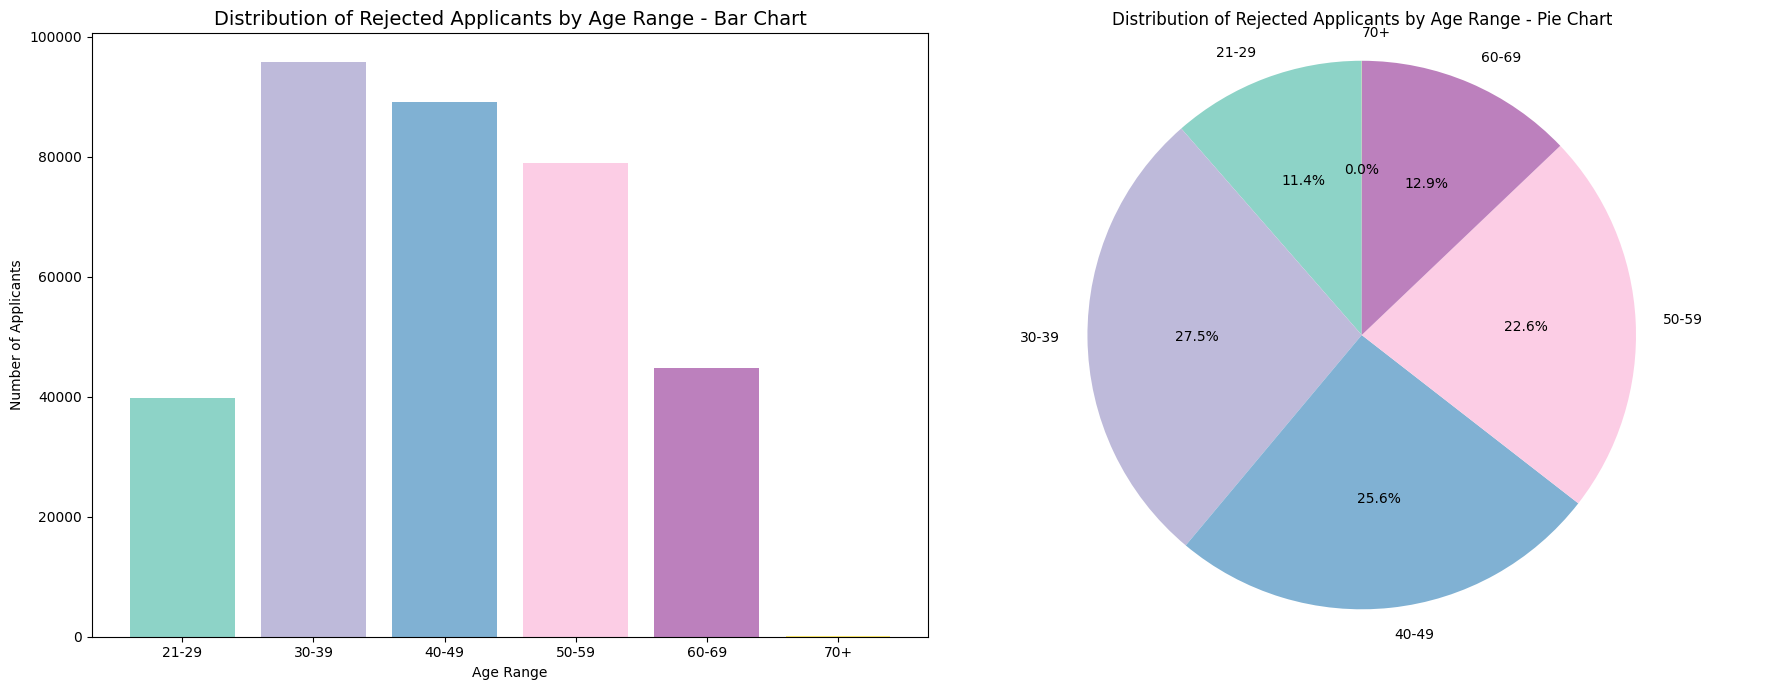

Age Distribution for Rejected Applicants:
AGE_RANGE
21-29    39830
30-39    95760
40-49    89101
50-59    78861
60-69    44847
70+         39
Name: count, dtype: int64


In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Custom age bins starting from 21
bins_age = [21, 30, 40, 50, 60, 69, rejected['AGE'].max() + 1]

labels_age = [
    '21-29',
    '30-39',
    '40-49',
    '50-59',
    '60-69',
    '70+',
]

# Correcting the data source from accepted['AGE'] to rejected['AGE']
rejected['AGE_RANGE'] = pd.cut(
    rejected['AGE'],
    bins=bins_age,
    labels=labels_age,
    right=False
)

# Distribution calculation
age_distribution_r = (
    rejected['AGE_RANGE']
    .value_counts()
    .sort_index()
)

# Create figure
plt.figure(figsize=(18, 7))

# BAR CHART
plt.subplot(1, 2, 1)
plt.bar(
    age_distribution_r.index.astype(str),
    age_distribution_r.values,
    color=plt.cm.Set3(np.linspace(0, 1, len(age_distribution_r)))
)
plt.title('Distribution of Rejected Applicants by Age Range - Bar Chart', fontsize=14)
plt.xlabel('Age Range')
plt.ylabel('Number of Applicants')

# PIE CHART
plt.subplot(1, 2, 2)
# Check if there are non-zero values to avoid pie chart errors
if age_distribution_r.sum() > 0:
    wedges, texts, autotexts = plt.pie(
        age_distribution_r.values,
        labels=age_distribution_r.index.astype(str),
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Set3(np.linspace(0, 1, len(age_distribution_r)))
    )

    # Hide labels for very small or zero slices to prevent overlap/errors
    for i, val in enumerate(age_distribution_r.values):
        if val == 0:
            texts[i].set_visible(False)
            autotexts[i].set_visible(False)

plt.title('Distribution of Rejected Applicants by Age Range - Pie Chart')
plt.axis('equal')

plt.tight_layout()
plt.show()

print("Age Distribution for Rejected Applicants:")
print(age_distribution_r)

### 2.2.3 Income

/tmp/ipykernel_664/893549101.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rejected['INCOME_RANGE'] = pd.cut(


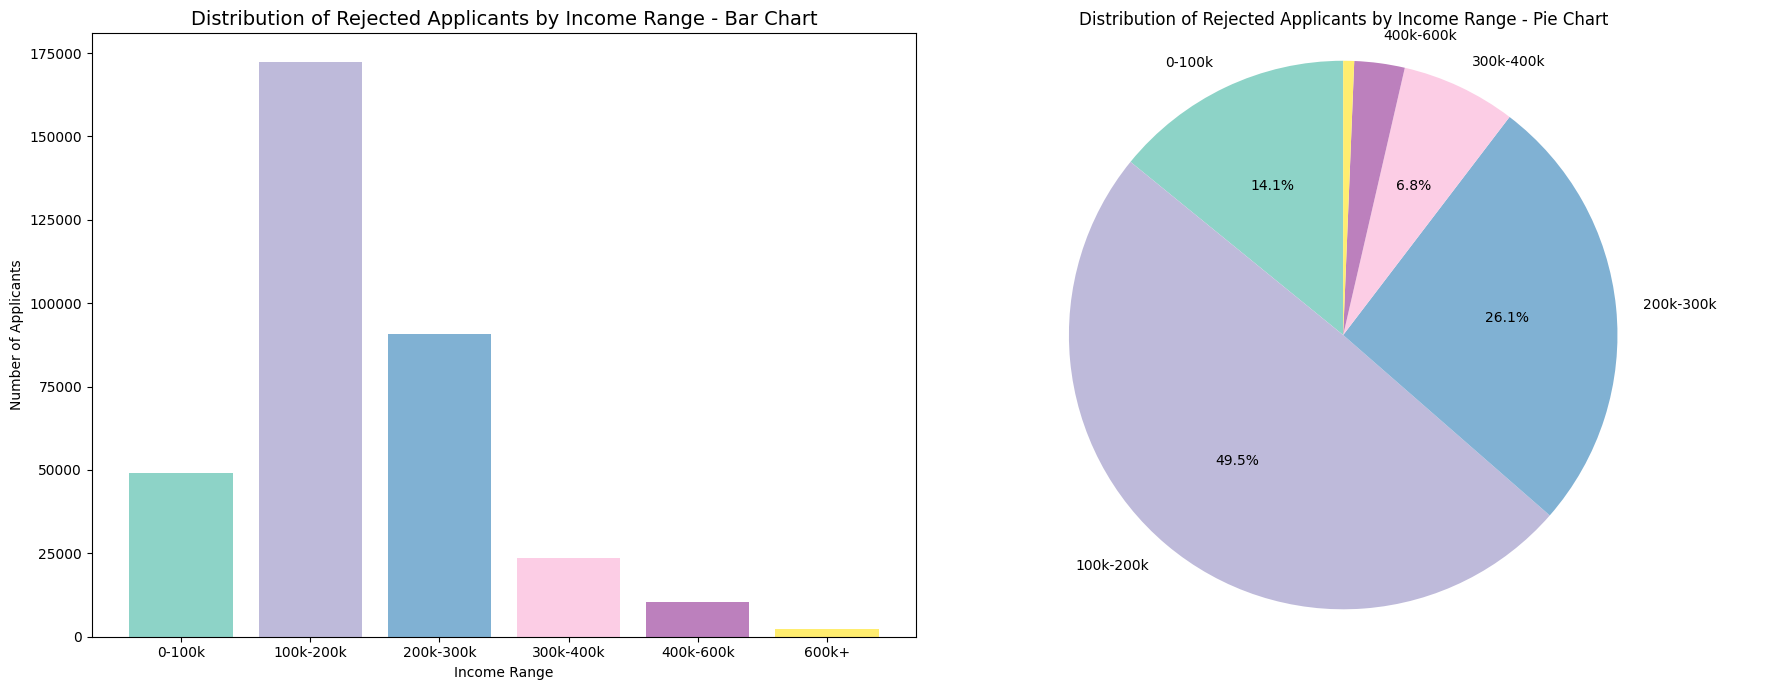

In [40]:
bins_income = [0, 100000, 200000, 300000, 400000, 600000, rejected['AMT_INCOME_TOTAL'].max()+1]

labels_income = [
    '0-100k',
    '100k-200k',
    '200k-300k',
    '300k-400k',
    '400k-600k',
    '600k+'
]

rejected['INCOME_RANGE'] = pd.cut(
    rejected['AMT_INCOME_TOTAL'],
    bins=bins_income,
    labels=labels_income,
    right=False)

# Distribution
income_distribution_r = (
    rejected['INCOME_RANGE']
    .value_counts()
    .sort_index())

income_distribution_r

plt.figure(figsize=(18,7))

# BAR CHART
plt.subplot(1,2,1)

plt.bar(
    income_distribution_r.index.astype(str),
    income_distribution_r.values,
    color=plt.cm.Set3(np.linspace(0,1,len(income_distribution_r)))
)

plt.title('Distribution of Rejected Applicants by Income Range - Bar Chart', fontsize=14)
plt.xlabel('Income Range')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)

# PIE CHART
plt.subplot(1,2,2)

sorted_indices = income_distribution_r.argsort().tolist()
smallest_1 = sorted_indices[0]
smallest_2 = sorted_indices[1]

wedges, texts, autotexts = plt.pie(
    income_distribution_r.values,
    labels=income_distribution_r.index.astype(str),
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3(np.linspace(0,1,len(income_distribution_r)))
)

# Hide smallest slices
autotexts[smallest_1].set_visible(False)
texts[smallest_1].set_visible(False)
autotexts[smallest_2].set_visible(False)

plt.title('Distribution of Rejected Applicants by Income Range - Pie Chart')
plt.axis('equal')

plt.tight_layout()
plt.show()

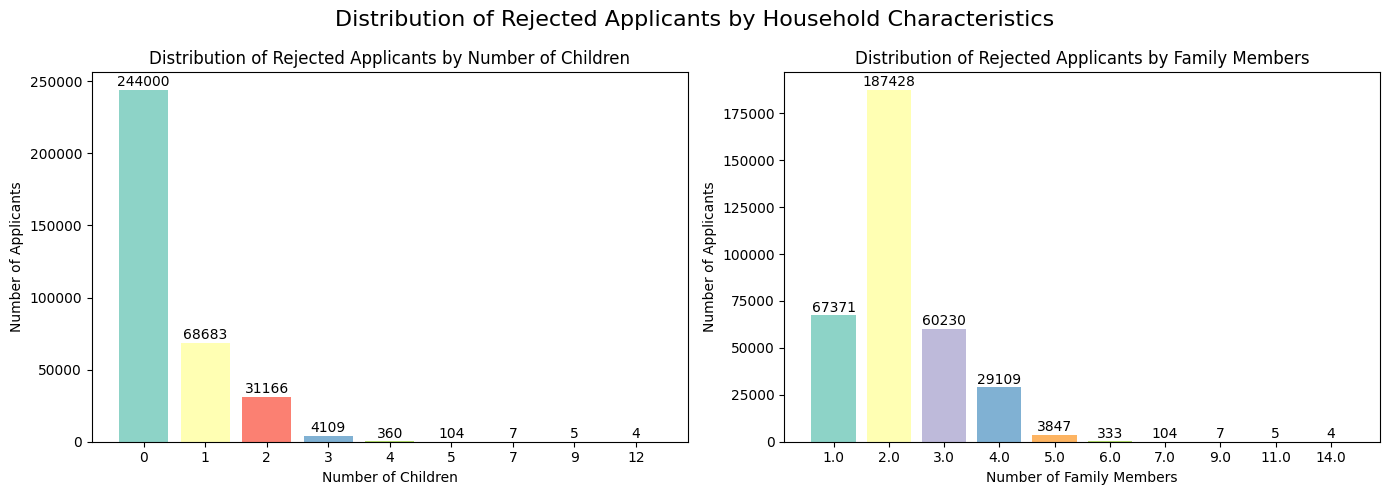

In [41]:
plt.figure(figsize=(14,5))

# CHILDREN
plt.subplot(1,2,1)

children_counts_r = rejected['CNT_CHILDREN'].value_counts().sort_index()

plt.bar(
    children_counts_r.index.astype(str),
    children_counts_r.values,
    color=plt.cm.Set3(np.linspace(0,1,len(children_counts_r)))
)

plt.title("Distribution of Rejected Applicants by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Number of Applicants")

for i,v in enumerate(children_counts_r.values):
    plt.text(i, v + max(children_counts_r.values)*0.01, str(v), ha='center')

# FAMILY MEMBER
plt.subplot(1,2,2)

family_counts_r = rejected['CNT_FAM_MEMBERS'].value_counts().sort_index()

plt.bar(
    family_counts_r.index.astype(str),
    family_counts_r.values,
    color=plt.cm.Set3(np.linspace(0,1,len(family_counts_r)))
)

plt.title("Distribution of Rejected Applicants by Family Members")
plt.xlabel("Number of Family Members")
plt.ylabel("Number of Applicants")

for i,v in enumerate(family_counts_r.values):
    plt.text(i, v + max(family_counts_r.values)*0.01, str(v), ha='center')

plt.suptitle("Distribution of Rejected Applicants by Household Characteristics", fontsize=16)

plt.tight_layout()
plt.show()

### 2.2.4 Categorical Feature

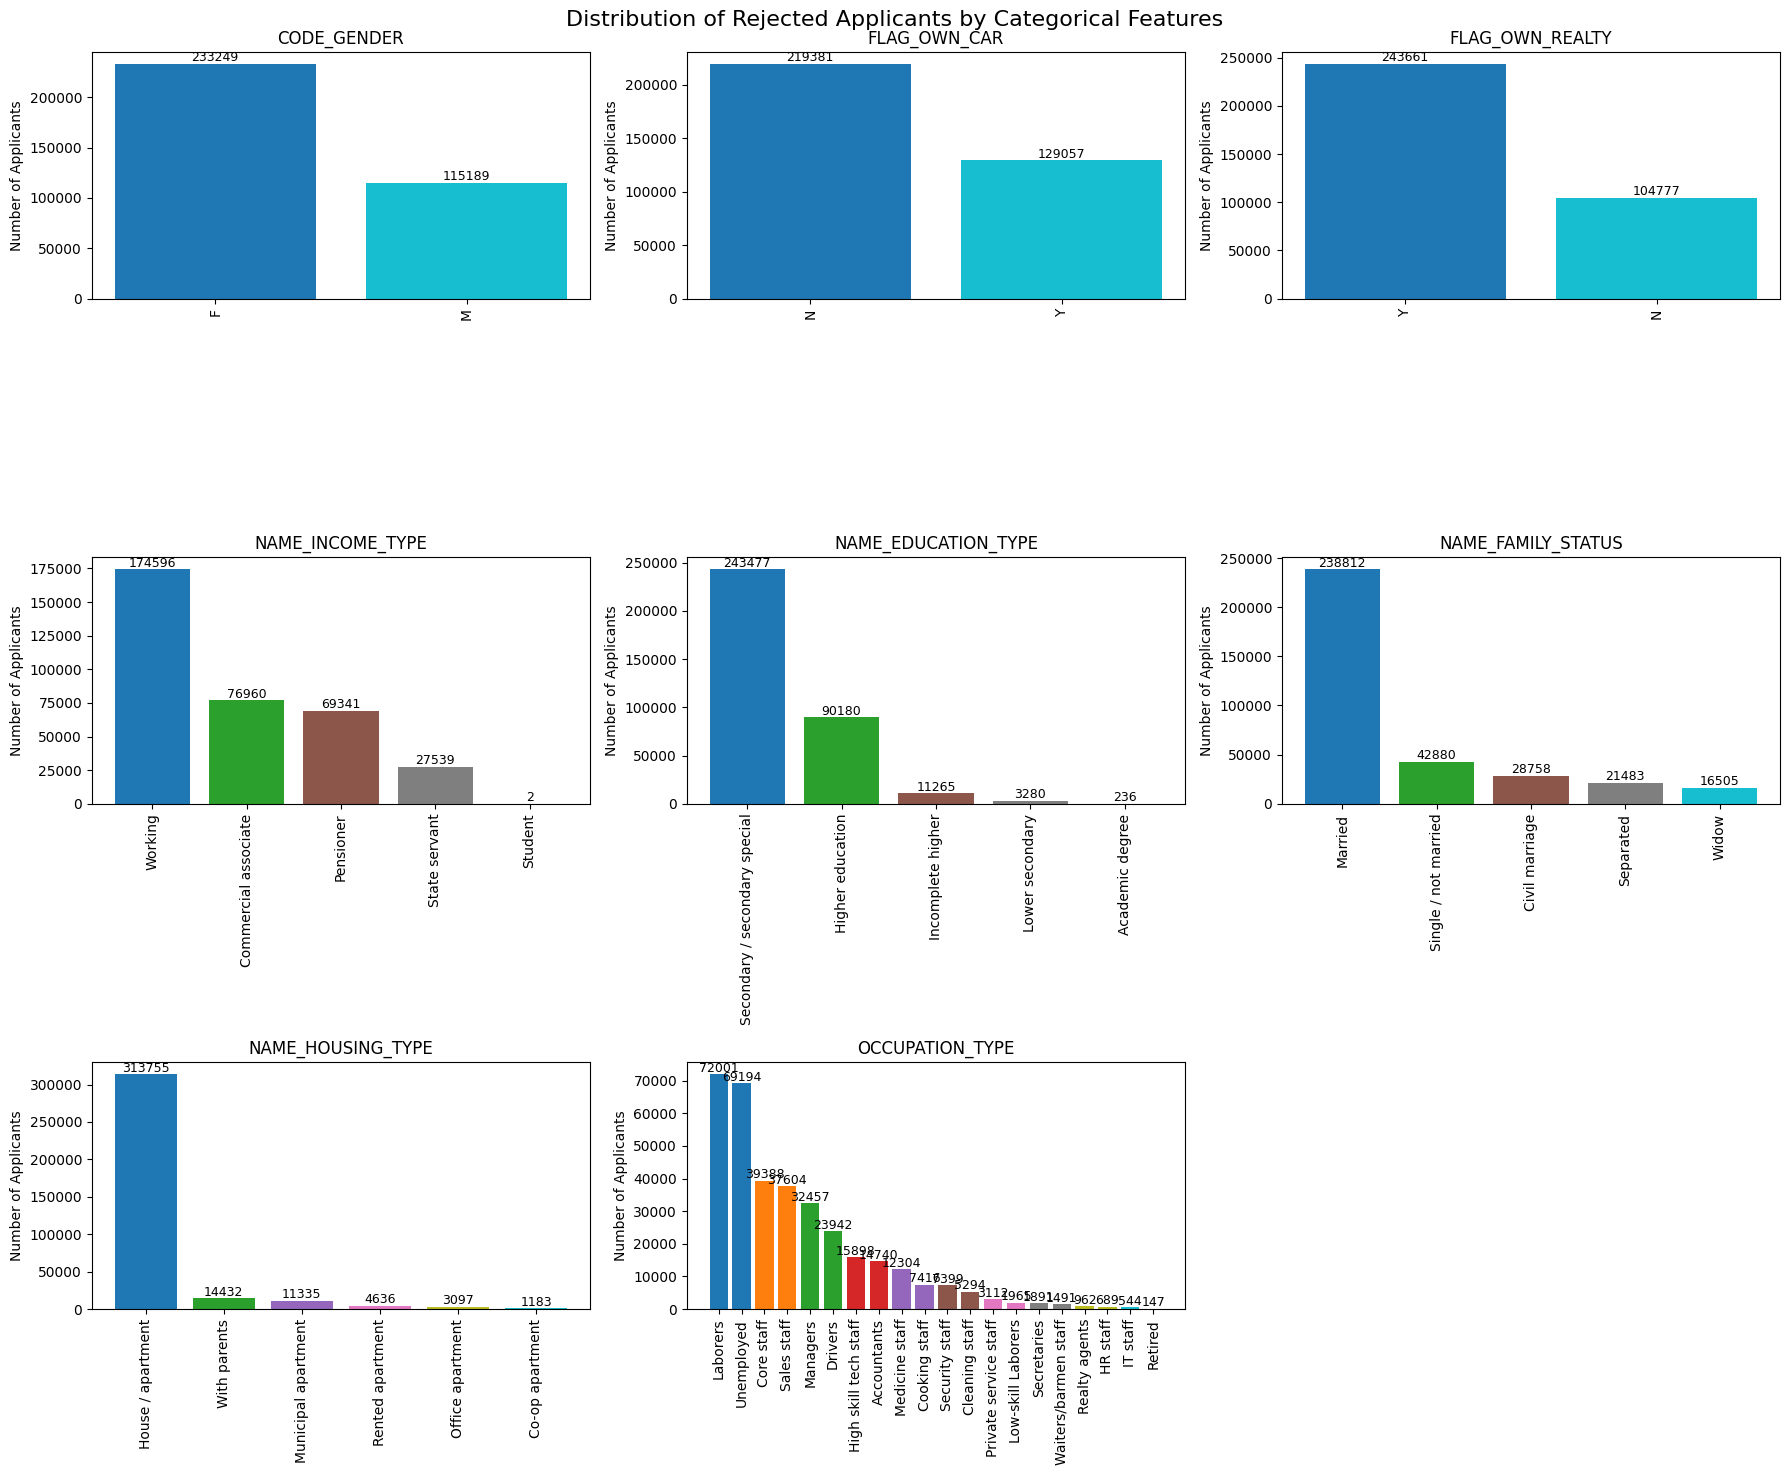

In [42]:
import math

categorical_columns_r = [
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]

# layout
num_cols = 3
num_rows = math.ceil(len(categorical_columns_r) / num_cols)

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(num_rows, num_cols, i)

    counts = rejected[col].value_counts()

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color=plt.cm.tab10(np.linspace(0, 1, len(counts)))
    )

    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Number of Applicants')
    plt.xticks(rotation=90)

      # value labels
    for j, v in enumerate(counts.values):
        plt.text(j, v + max(counts.values) * 0.01, str(v), ha='center', fontsize=9)



plt.suptitle('Distribution of Rejected Applicants by Categorical Features', fontsize=16)
plt.tight_layout()
plt.show()

## 3. Correlation Analysis


### 3.1 Encoding Categorical Variables

Machine learning algorithms require numerical inputs.  
Therefore, categorical variables such as occupation, housing type, and income category are converted into numerical representations through encoding techniques.  
This transformation allows the dataset to be used effectively in predictive models.

In [43]:
# Selecting the coluns with categorical data
cat_cols = data.select_dtypes(include=['object']).columns

# Using get_dummies to One-Hot Encode all nominal columns at once
data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)

In [44]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379711 entries, 0 to 379710
Data columns (total 50 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   ID                                                 379711 non-null  int64  
 1   CNT_CHILDREN                                       379711 non-null  int64  
 2   AMT_INCOME_TOTAL                                   379711 non-null  float64
 3   FLAG_MOBIL                                         379711 non-null  int64  
 4   FLAG_WORK_PHONE                                    379711 non-null  int64  
 5   FLAG_PHONE                                         379711 non-null  int64  
 6   FLAG_EMAIL                                         379711 non-null  int64  
 7   CNT_FAM_MEMBERS                                    379711 non-null  float64
 8   Status                                             379711 non-null  int64 

### 3.2 Dropping unnecessary columns

In [45]:
# Dropping the ID and FLAG_MOBIL columns
columns_to_drop = ['ID', 'FLAG_MOBIL']
data_encoded = data_encoded.drop(columns=columns_to_drop, errors='ignore')

In [46]:
# Moving the status column to the end
cols = [col for col in data_encoded.columns if col != 'Status']
cols.append('Status')
data_final = data_encoded[cols]

### 3.3 Correlation Analysis

A correlation matrix is created to examine the relationships between variables.  
This helps identify which features are most strongly associated with the target variable (credit approval status).  
Understanding these relationships provides useful insights before building predictive models.

In [47]:
corr_matrix = data_final.corr()
corr_matrix

,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,CODE_GENDER_M,FLAG_OWN_CAR_Y,...,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Retired,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unemployed,OCCUPATION_TYPE_Waiters/barmen staff,Status
CNT_CHILDREN,1.000000,0.021907,0.044650,-0.041587,0.026550,0.883481,-0.360720,0.051416,0.089806,0.118195,...,0.009626,0.017550,0.008761,0.001672,0.043026,0.005153,0.001470,-0.260452,0.010220,0.001615
AMT_INCOME_TOTAL,0.021907,1.000000,-0.026874,0.000053,0.107721,0.014829,-0.060544,0.083144,0.169147,0.189790,...,-0.031896,0.012818,0.017291,0.005305,-0.049085,-0.011290,-0.022078,-0.147842,-0.016539,-0.002366
FLAG_WORK_PHONE,0.044650,-0.026874,1.000000,0.288219,-0.059467,0.055846,-0.188237,0.118342,0.031499,0.013267,...,0.018540,0.014000,0.012481,0.003295,0.053826,0.011258,0.015325,-0.247900,0.009765,0.015889
FLAG_PHONE,-0.041587,0.000053,0.288219,1.000000,-0.004246,-0.026378,0.036518,0.036015,-0.023307,-0.005055,...,-0.009442,-0.000561,-0.002433,-0.001424,-0.007192,0.010092,-0.002760,0.006783,-0.000351,0.003201
FLAG_EMAIL,0.026550,0.107721,-0.059467,-0.004246,1.000000,0.021205,-0.097128,0.000927,0.010517,0.036483,...,-0.006885,0.004537,0.003301,0.001111,0.012573,0.012716,-0.012143,-0.078496,0.003021,-0.017286
CNT_FAM_MEMBERS,0.883481,0.014829,0.055846,-0.026378,0.021205,1.000000,-0.318682,0.070166,0.118544,0.160069,...,0.007111,0.007299,0.007955,0.000365,0.033718,0.005294,0.005312,-0.253412,-0.000803,0.000502
AGE,-0.360720,-0.060544,-0.188237,0.036518,-0.097128,-0.318682,1.000000,-0.053424,-0.199572,-0.169568,...,-0.023931,-0.036151,-0.016434,-0.003897,-0.170122,-0.029418,0.005243,0.648893,-0.039309,-0.000994
YEARS_EMPLOYED,0.051416,0.083144,0.118342,0.036015,0.000927,0.070166,-0.053424,1.000000,-0.006734,0.043894,...,0.157393,0.012202,-0.003819,0.005751,-0.040221,0.018664,0.000385,-0.437498,0.001504,0.000982
CODE_GENDER_M,0.089806,0.169147,0.031499,-0.023307,0.010517,0.118544,-0.199572,-0.006734,1.000000,0.353454,...,-0.124668,-0.059892,-0.024871,0.003705,-0.149734,-0.045418,0.104353,-0.186324,-0.027510,0.001262
FLAG_OWN_CAR_Y,0.118195,0.189790,0.013267,-0.005055,0.036483,0.160069,-0.169568,0.043894,0.353454,1.000000,...,-0.043788,-0.002014,-0.001166,0.001092,-0.046399,-0.011742,0.019431,-0.180512,-0.024231,0.004038


### 3.4 Visualizing the correlation using a Sorted correlation Bar Chart.

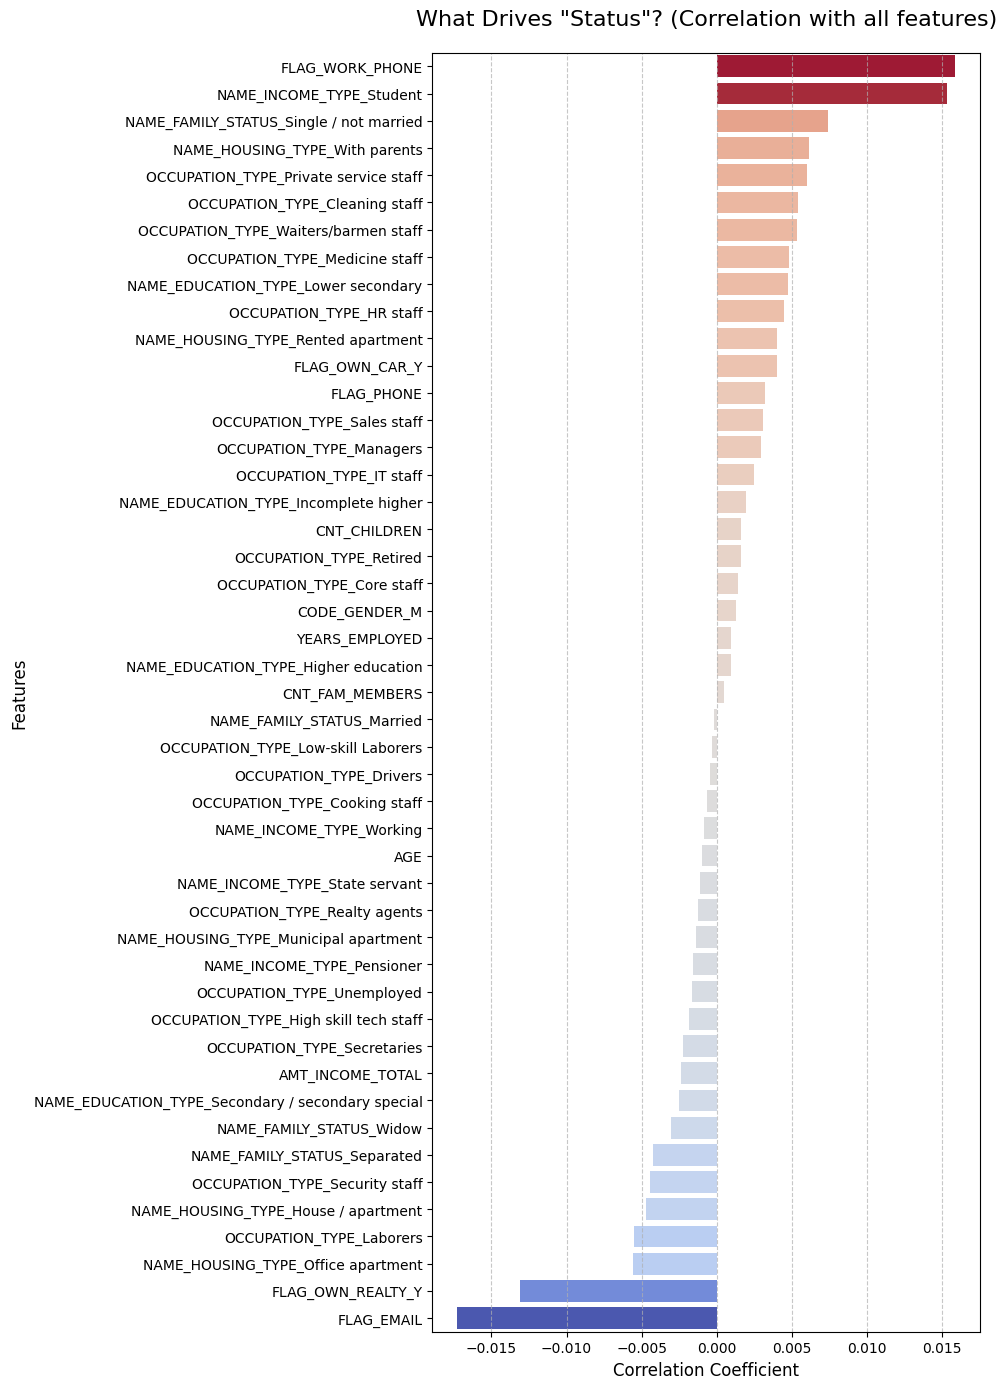

In [48]:
import seaborn as sns
status_corr = data_final.corr()['Status'].drop('Status')

# Sorting the values from highest positive correlation to lowest negative
status_corr_sorted = status_corr.sort_values(ascending=False)

# Creating a tall, easy-to-read Bar Chart
plt.figure(figsize=(10, 14)) # Make it tall enough to comfortably fit all your text labels!
sns.barplot(x=status_corr_sorted.values, y=status_corr_sorted.index, hue=status_corr_sorted.values, palette='coolwarm', legend=False)

# Adding clean labels and formatting
plt.title('What Drives "Status"? (Correlation with all features)', fontsize=16, pad=20)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Adds vertical guide-lines
plt.tight_layout()
plt.show()

### 3.5 Visualizing the correlation of each variable with Status while Accepted or Not for each feature, higher the bar, higher correlation.


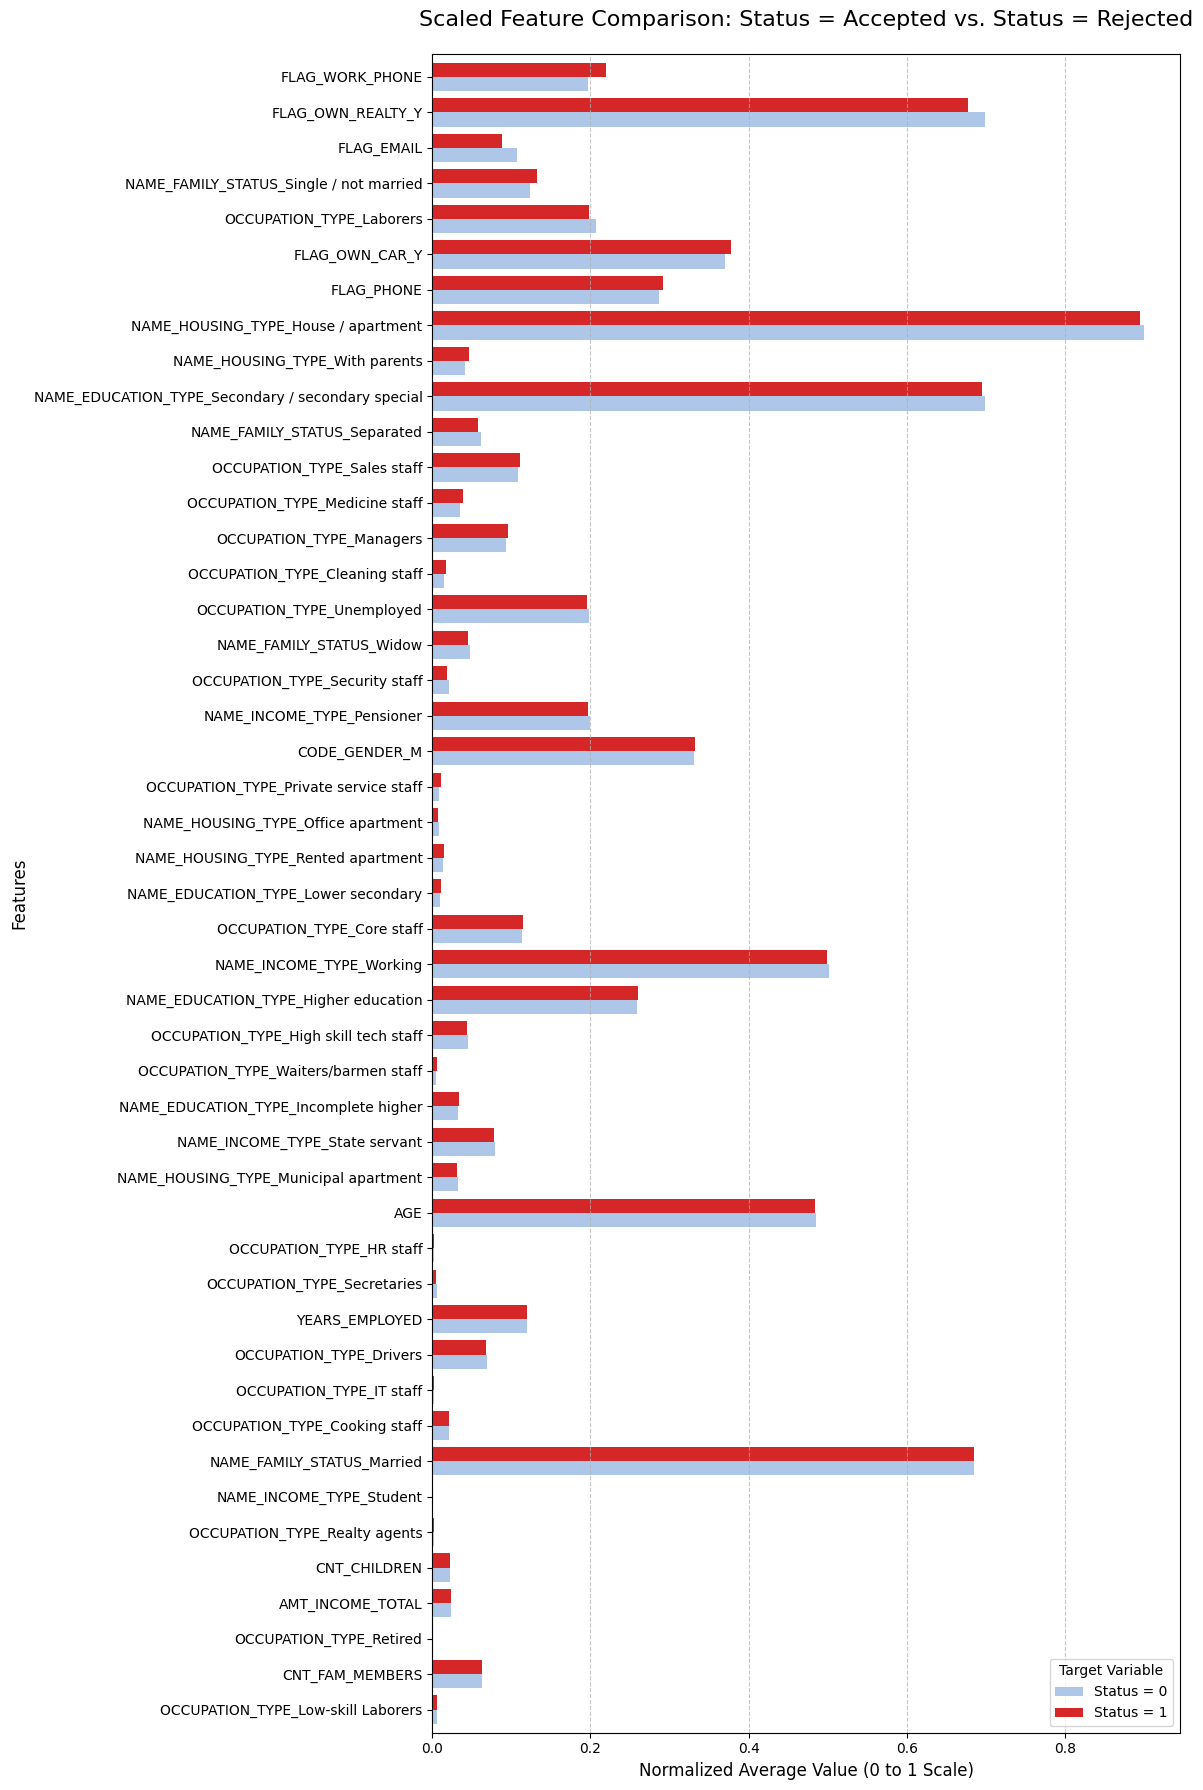

In [49]:
from sklearn.preprocessing import MinMaxScaler
# Separate the features from the target 'Status'
features = data_final.drop(columns=['Status'])
target = data_final['Status'].values

# Scaling all features to exist exactly between 0 and 1
scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(features)

# Turn it back into a Pandas dataframe and re-attach 'status'
scaled_data = pd.DataFrame(scaled_array, columns=features.columns)
scaled_data['Status'] = target

# Grouping by 'status' and calculate the average
grouped_data = scaled_data.groupby('Status').mean().T
grouped_data.columns = ['Status = 0', 'Status = 1']

# Sorting the data by the biggest differences so the most important features are at the top
grouped_data['Difference'] = abs(grouped_data['Status = 1'] - grouped_data['Status = 0'])
grouped_data_sorted = grouped_data.sort_values(by='Difference', ascending=True)
grouped_data_sorted = grouped_data_sorted.drop(columns=['Difference']) # Drop so it doesn't plot

# Plotting the fully visible Grouped Bar Chart!
grouped_data_sorted.plot(kind='barh', figsize=(12, 18), color=['#aec7e8', '#d62728'], width=0.8)

# Clean up the formatting
plt.title('Scaled Feature Comparison: Status = Accepted vs. Status = Rejected', fontsize=16, pad=20)
plt.xlabel('Normalized Average Value (0 to 1 Scale)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.legend(title='Target Variable', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 4. Machine Learning models

### Splitting the Dataset

The dataset is divided into training and testing subsets.  
The training data is used to build the machine learning models, while the testing data is used to evaluate how well the models perform on unseen data.  
This approach helps ensure that the model generalizes well to new observations.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
X = data_final.drop(columns=['Status'])
y = data_final['Status']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Divided Data - X_train: {X_train.shape}, X_test: {X_test.shape}\n")

 Divided Data - X_train: (303768, 47), X_test: (75943, 47)



### 4.1 Logistic Regression Model

Logistic Regression is used as a baseline classification model.  
It estimates the probability that an applicant belongs to the accepted or rejected category based on the input features.

This model is widely used in financial risk analysis because it provides interpretable results and helps understand how different factors influence credit approval.

In [53]:
log_reg = LogisticRegression(max_iter=3000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test) # INFERENCE
acc_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {acc_log * 100:.2f}%")

Logistic Regression Accuracy: 91.73%


### 4.2 Random Forest Model

Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions.  
This approach helps capture complex relationships between applicant characteristics and credit approval outcomes.

Random Forest models are often more powerful than simple models because they reduce overfitting and improve prediction accuracy.

In [54]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test) # INFERENCE
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f" Random Forest Accuracy:       {acc_rf * 100:.2f}%")

 Random Forest Accuracy:       97.36%


### 4.3 Model Evaluation

The performance of the models is evaluated using confusion matrices and classification reports.  
These metrics help measure how accurately the models classify applicants as accepted or rejected.

Evaluating model performance ensures that the predictive models provide reliable results before being considered for real-world applications.

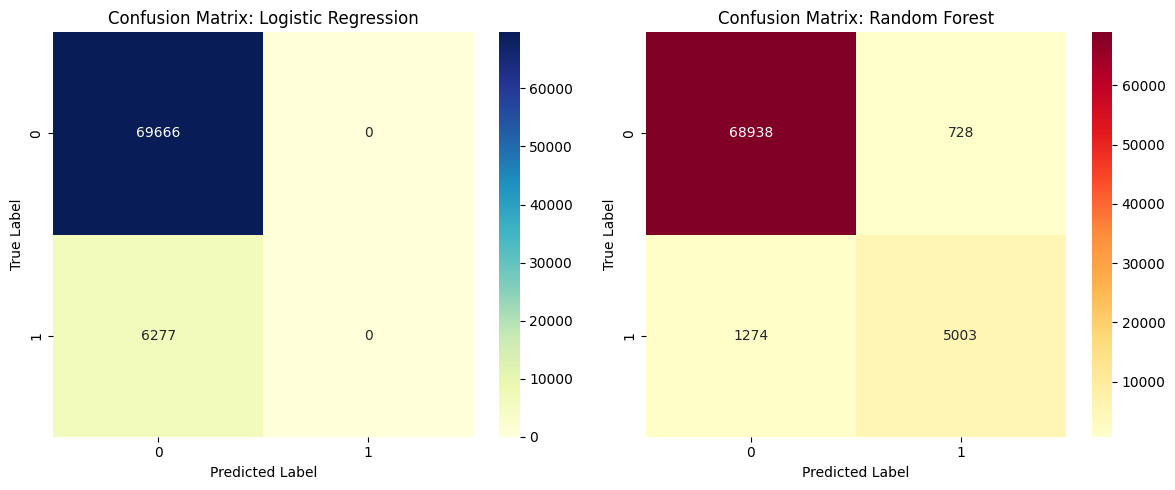

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Confusion Matrix: Random Forest')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### 4.4 Comparision of both models

In [56]:
print("\n--- Classification Report: Logistic Regression ---")
print(classification_report(y_test, y_pred_log))

print("\n--- Classification Report: Random Forest ---")
print(classification_report(y_test, y_pred_rf))


--- Classification Report: Logistic Regression ---
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     69666
           1       0.00      0.00      0.00      6277

    accuracy                           0.92     75943
   macro avg       0.46      0.50      0.48     75943
weighted avg       0.84      0.92      0.88     75943


--- Classification Report: Random Forest ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     69666
           1       0.87      0.80      0.83      6277

    accuracy                           0.97     75943
   macro avg       0.93      0.89      0.91     75943
weighted avg       0.97      0.97      0.97     75943



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 4.5 Feature Importance Analysis

Feature importance analysis from the Random Forest model helps identify which variables have the greatest influence on the prediction outcome.  
Understanding these important features provides valuable business insights into the key factors that affect credit approval decisions.

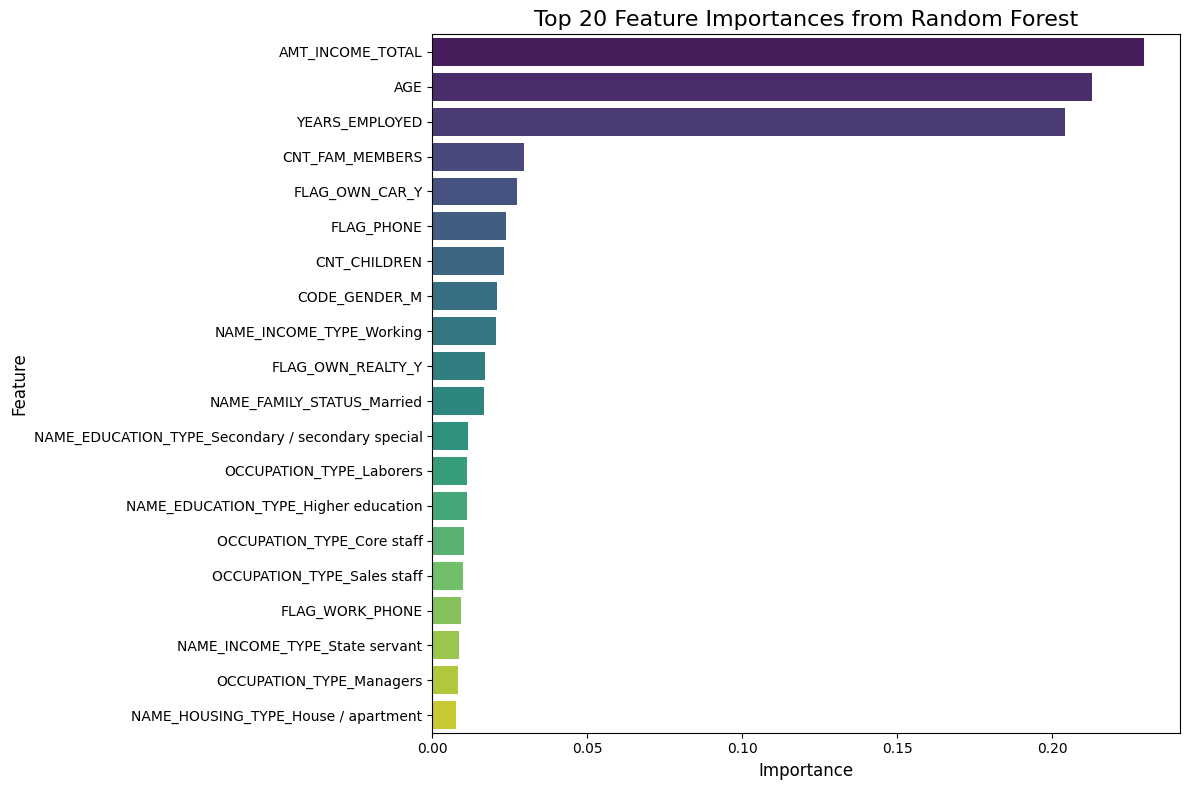

In [57]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df.head(20), palette='viridis', legend=False)
plt.title('Top 20 Feature Importances from Random Forest', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

## Key Insight from the Analysis

Overall, the analysis demonstrates that machine learning techniques can support financial institutions in making more informed credit approval decisions. By analyzing applicant demographic and financial information, predictive models such as Logistic Regression and Random Forest can identify patterns associated with credit risk. These insights can help banks improve risk assessment, reduce default rates, and enhance the efficiency of the credit evaluation process.